In [28]:
import os
from datetime import datetime

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline   
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix


import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [29]:
df = pd.read_csv('../data/raw/conversion_data_train.csv')

In [30]:
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


## Preprocessing :

In [31]:
target = "converted"

X = df.drop(columns=[target])
y = df[target].astype(int)

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ]
)

/var/folders/p7/7w66qcfn4yj82k3sbs5fp74h0000gn/T/ipykernel_59265/1525777770.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## Gridsearch + Random forest

In [32]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=0, n_jobs=-1))
])

param_grid = {
    "clf__n_estimators": [200],
    "clf__max_depth": [8, 12, None],
    "clf__min_samples_leaf": [1, 5, 20],
    "clf__max_features": ["sqrt", 0.5],
    "clf__class_weight": [None, "balanced_subsample", "balanced"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_rf = grid.best_estimator_

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_samples_leaf=20, clf__n_estimators=200; total time=  12.9s
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=200; total time=  14.4s
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=200; total time=  14.6s
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_samples_leaf=20, clf__n_estimators=200; total time=  15.4s
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_samples_leaf=1, clf__n_estimators=200; total time=  15.5s
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__n_estimators=200; total time=  15.9s
[CV] END clf__class_weight=None, clf__max_depth=8, clf__max_features=sqrt, clf__min_

## Model evaluation

In [33]:
def evaluate_model(name, pipe, X_test, y_test):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    metrics = {
        "model": name,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    return metrics, y_pred, y_proba

In [34]:
rf_metrics, ypred_rf, yproba_rf = evaluate_model("RandomForest", best_rf, X_test, y_test)

,model,f1,precision,recall,roc_auc
0,RandomForest,0.765,0.8573,0.6906,0.9858


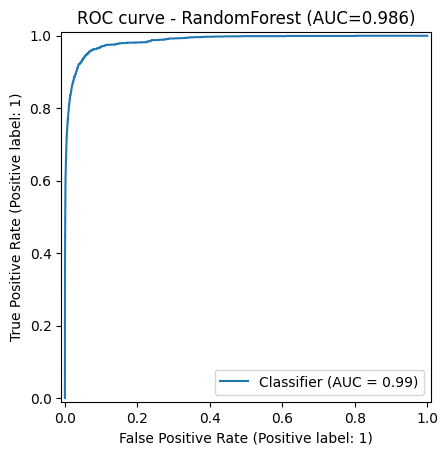

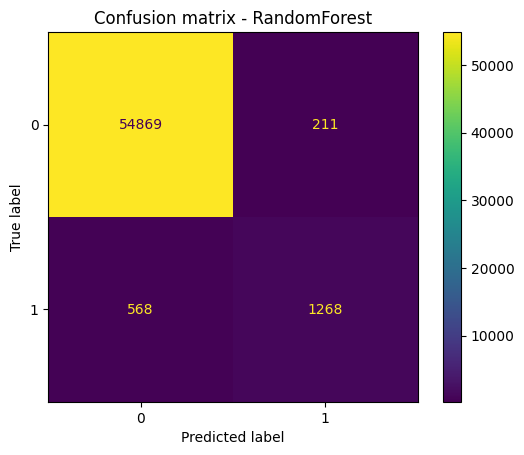

In [35]:
results_df = pd.DataFrame([rf_metrics])
display(results_df.round(4))

RocCurveDisplay.from_predictions(y_test, yproba_rf)
plt.title(f"ROC curve - {rf_metrics['model']} (AUC={rf_metrics['roc_auc']:.3f})")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, ypred_rf, values_format="d")
plt.title(f"Confusion matrix - {rf_metrics['model']}")
plt.show()

## Saving logs

In [36]:
results_path = "../data/logs/model_logs.csv"
os.makedirs(os.path.dirname(results_path), exist_ok=True)

row = rf_metrics.copy()
row["timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

row_df = pd.DataFrame([row])

if os.path.exists(results_path):
    row_df.to_csv(results_path, mode="a", header=False, index=False)
else:
    row_df.to_csv(results_path, mode="w", header=True, index=False)

print(f"Résultats ajoutés à {results_path}")

Résultats ajoutés à ../data/logs/model_logs.csv


## Retraining on whole dataset

In [37]:
target = "converted"
X_full = df.drop(columns=[target])
y_full = df[target].astype(int)

rf_pipe.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## Charging unlabeled data

In [38]:
df_unlabeled = pd.read_csv("../data/raw/conversion_data_test.csv")

feature_cols = X_full.columns.tolist()
df_unlabeled = df_unlabeled[feature_cols]

y_proba = rf_pipe.predict_proba(df_unlabeled)[:, 1]
y_pred  = rf_pipe.predict(df_unlabeled)

In [39]:
output_file = Path("../data/results/conversion_data_test_predictions_randomforest.csv")


output_file.parent.mkdir(parents=True, exist_ok=True)


submission = pd.DataFrame({
    "converted": y_pred
})
submission.to_csv(output_file, index=False)

## Feature importance analysis

In [40]:
feature_names_cat = (
    best_rf.named_steps["prep"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

feature_names_num = numeric_features

feature_names = np.concatenate([
    feature_names_num,
    feature_names_cat
])

importances = best_rf.named_steps["clf"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
2,total_pages_visited,0.884013
1,new_user,0.042562
3,country_China,0.037168
0,age,0.026903
6,country_US,0.002543
5,country_UK,0.001988
7,source_Ads,0.001291
8,source_Direct,0.001263
4,country_Germany,0.001145
9,source_Seo,0.001124


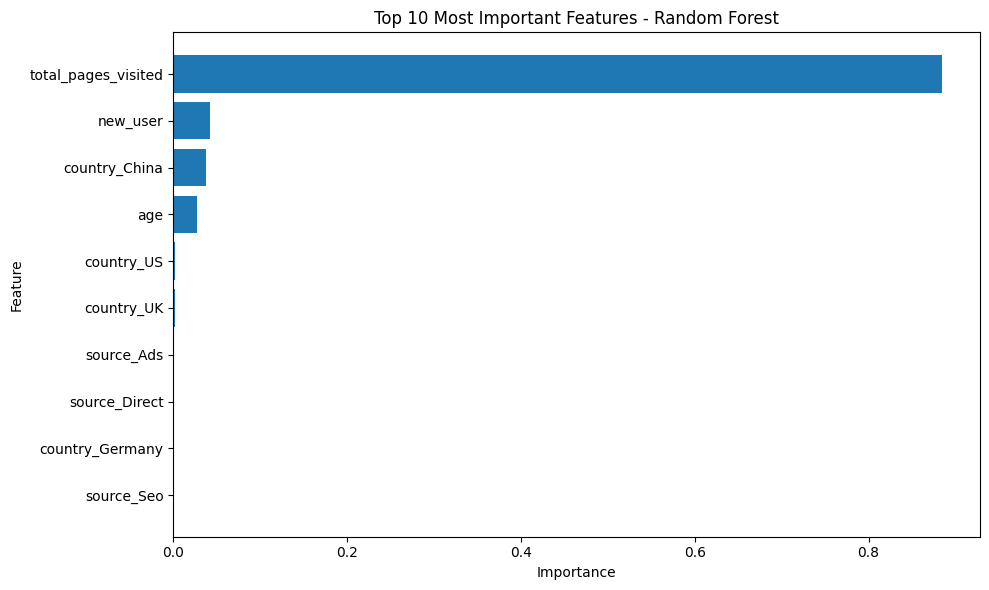

In [41]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["feature"].head(10)[::-1],
    feature_importance_df["importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Random Forest")

plt.tight_layout()
plt.show()

## Analysis of Random Forest

The Random Forest model highlights one very important point: users who visit more pages are much more likely to subscribe to the newsletter.
`total_pages_visited` is clearly the strongest feature in the model, which means user engagement plays a major role in conversions.

The model also shows that:

* returning users behave differently from new visitors,
* conversion rates vary depending on the country,
* age has a smaller but still noticeable impact.
